In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [29]:
df = pd.read_csv("pizza_sales.csv")
display(df.head())
display(df.shape)
display(df.columns)
display(df.info())

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


(48620, 12)

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


None

In [30]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


In [31]:
df.dtypes

pizza_id               int64
order_id               int64
pizza_name_id         object
quantity               int64
order_date            object
order_time            object
unit_price           float64
total_price          float64
pizza_size            object
pizza_category        object
pizza_ingredients     object
pizza_name            object
dtype: object

In [32]:
# Total revenue
total_revenue = df['total_price'].sum()
# Total pizzas sold
total_pizzas_sold = df['quantity'].sum()
# Total orders
total_orders = df['order_id'].nunique()
# Avg order value = Total Revenue / Total Orders
avg_order_value = total_revenue / total_orders
# Avg pizza per order = total pizzas sold / total orders
avg_pizza_per_order = total_pizzas_sold / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Pizzas Sold: {total_pizzas_sold:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Average Pizza per Order: {avg_pizza_per_order:.2f}")

Total Revenue: $817,860.05
Total Orders: 21,350
Total Pizzas Sold: 49,574
Average Order Value: $38.31
Average Pizza per Order: 2.32


In [33]:
from collections import Counter

# Flatten all ingredients into one list
all_ingredients = [
    ing.strip() for item in df['pizza_ingredients'] for ing in item.split(",")
]

# Count frequency of each ingredient
ingredient_df = (pd.DataFrame(Counter(all_ingredients).items(),
                             columns=["Ingredients", "Count"]).sort_values(by="Count", ascending=False))

print(ingredient_df.head())

          Ingredients  Count
12             Garlic  27422
15           Tomatoes  26601
5          Red Onions  19547
6         Red Peppers  16284
2   Mozzarella Cheese  10333


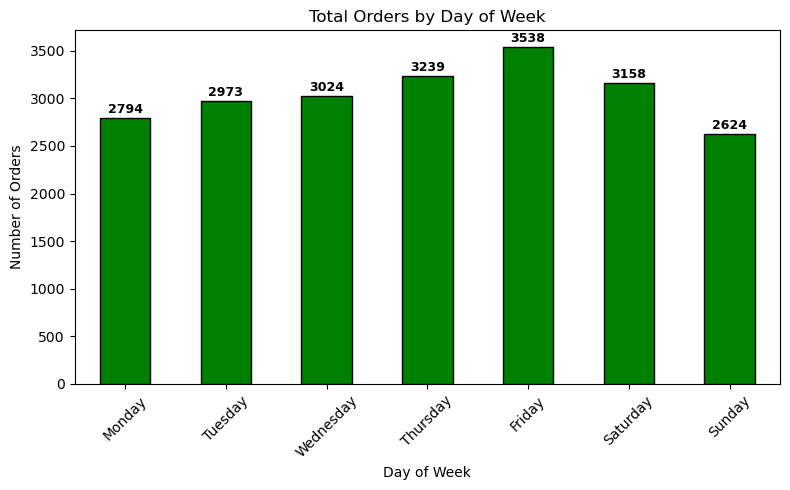

In [42]:
df["order_date"] = pd.to_datetime(df["order_date"], format="mixed", dayfirst=True) 
df['day_name'] = df['order_date'].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df["day_name"] = pd.Categorical(df["day_name"], categories=weekday_order, ordered=True)

orders_by_day = df.groupby("day_name", observed=False)['order_id'].nunique()

fig, ax = plt.subplots(figsize=(8, 5))

ax = orders_by_day.plot(kind="bar", color="green", edgecolor="black")
plt.title("Total Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
for i, val in enumerate(orders_by_day):
    plt.text(i, val + 20, str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

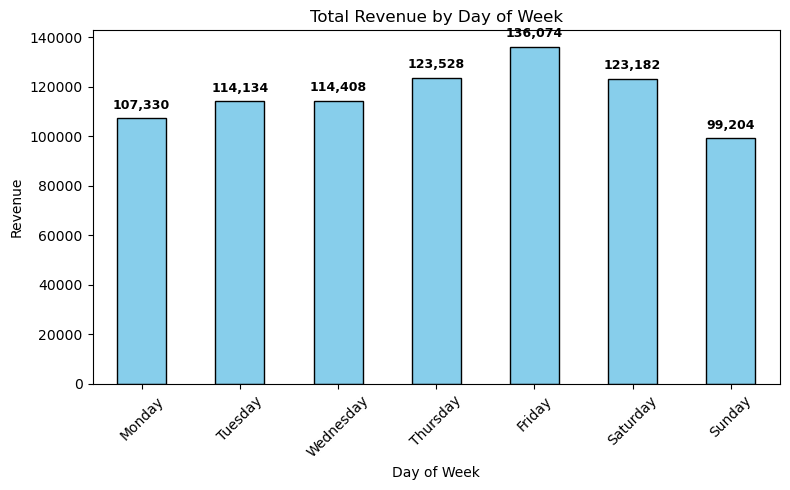

In [43]:
revenue_by_day = df.groupby("day_name", observed=False)["total_price"].sum()

fig, ax = plt.subplots(figsize=(8, 5))

ax = revenue_by_day.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Total Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

for i, val in enumerate(revenue_by_day):
    plt.text(i, val + (0.02*revenue_by_day.max()), f"{val:,.0f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

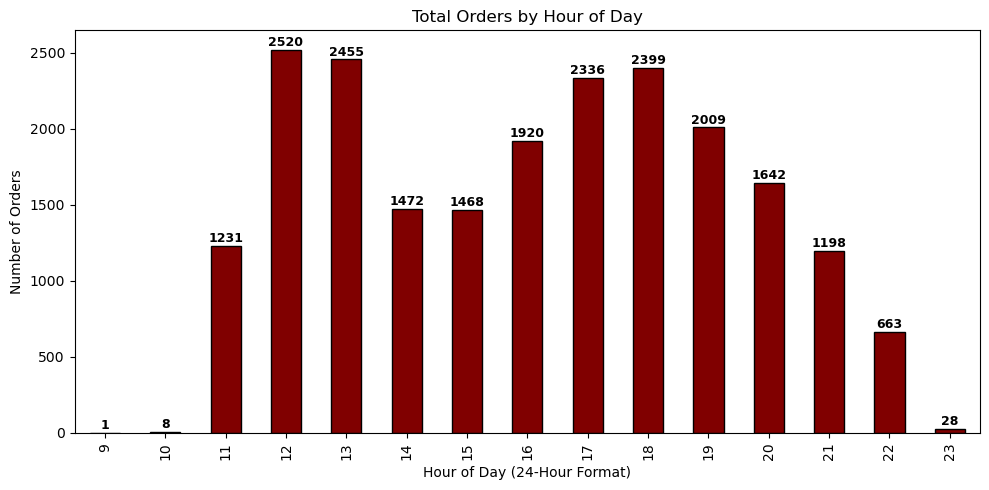

In [47]:
# Convert order_time to datetime
df["order_time"] = pd.to_datetime(df["order_time"], format="%H:%M:%S", errors="coerce")

# Extract the hour from order_time
df["order_hour"] = df["order_time"].dt.hour

# Group by hour and count unique orders
order_by_hour = df.groupby("order_hour", observed=False)["order_id"].nunique()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax = order_by_hour.plot(kind="bar", color="maroon", edgecolor='black')

plt.title("Total Orders by Hour of Day")
plt.xlabel("Hour of Day (24-Hour Format)")
plt.ylabel("Number of Orders")

# Annotate values on bars
for i, val in enumerate(order_by_hour):
    plt.text(i, val + 5, str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


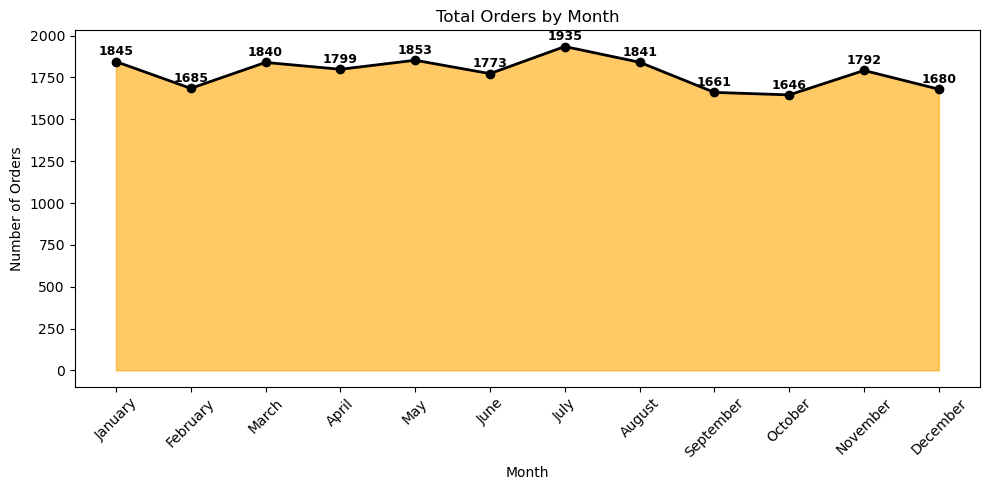

In [54]:
df['order_date'] = pd.to_datetime(df["order_date"], dayfirst=True)

df["month_name"] = df["order_date"].dt.month_name()

month_order = ["January", "February", "March", "April", "May", "June", "July", "August",
              "September", "October", "November", "December"]

df["month_name"] = pd.Categorical(df["month_name"], categories=month_order, ordered=True)

orders_by_month = df.groupby("month_name", observed=False)["order_id"].nunique()

plt.figure(figsize=(10, 5))
plt.fill_between(orders_by_month.index, orders_by_month.values, color="orange", alpha=0.6)
plt.plot(orders_by_month.index, orders_by_month.values, color="black", linewidth=2, marker='o')

plt.title("Total Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

for i, val in enumerate(orders_by_month):
    plt.text(i, val + 20, str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

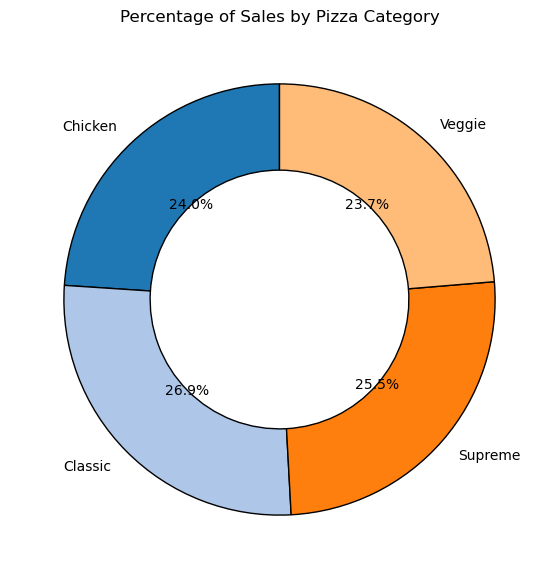

In [56]:
category_sales = df.groupby("pizza_category")["total_price"].sum()
category_pct = category_sales / category_sales.sum() * 100

plt.figure(figsize=(7, 7))
colors = plt.get_cmap('tab20').colors

plt.pie(category_pct, labels=category_pct.index, autopct="%1.1f%%", startangle=90, colors=colors,
        wedgeprops={"edgecolor":"black", "width":0.4})
plt.title("Percentage of Sales by Pizza Category")
plt.show()

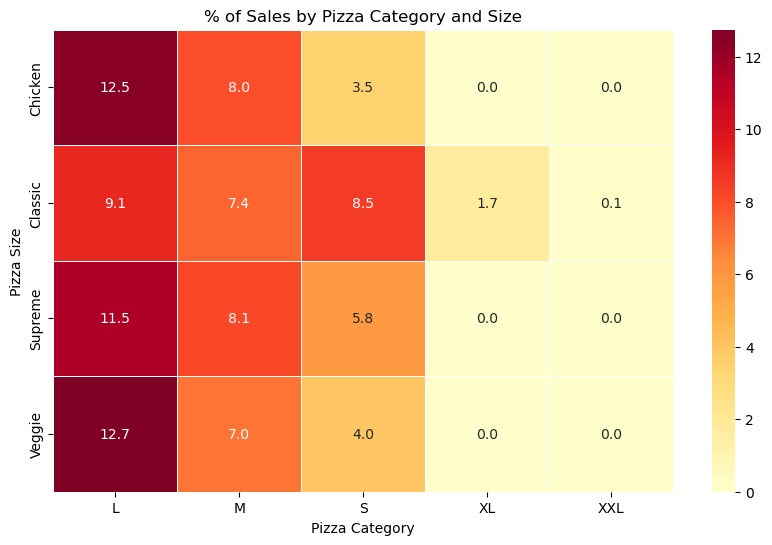

In [57]:
sales_pivot = df.pivot_table(
    index="pizza_category",
    columns="pizza_size",
    values="total_price",
    aggfunc="sum",
    fill_value=0
)

sales_pct = sales_pivot / sales_pivot.sum().sum() * 100

plt.figure(figsize=(10, 6))
sns.heatmap(sales_pct, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("% of Sales by Pizza Category and Size")
plt.xlabel("Pizza Category")
plt.ylabel("Pizza Size")
plt.show()

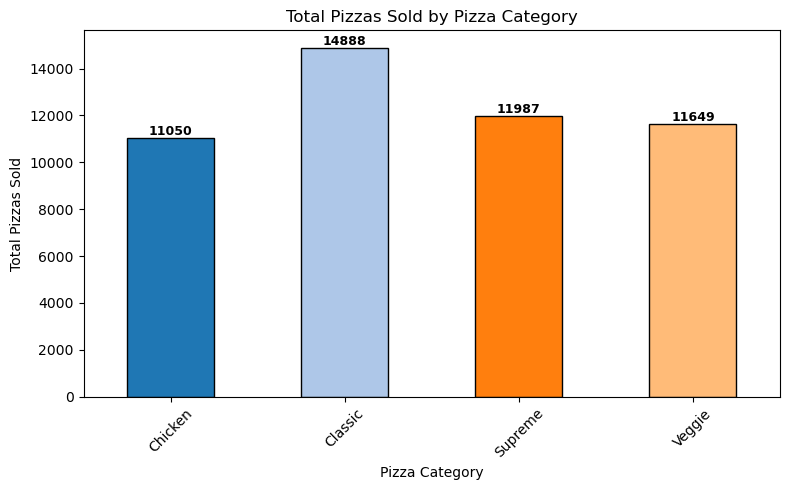

In [60]:
pizzas_by_category = df.groupby("pizza_category")["quantity"].sum()
colors = list(plt.get_cmap("tab20").colors)

plt.figure(figsize=(8, 5))
ax = pizzas_by_category.plot(kind="bar", color=colors, edgecolor='black')

plt.title("Total Pizzas Sold by Pizza Category")
plt.xlabel("Pizza Category")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(pizzas_by_category):
    plt.text(i, val + 5, str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


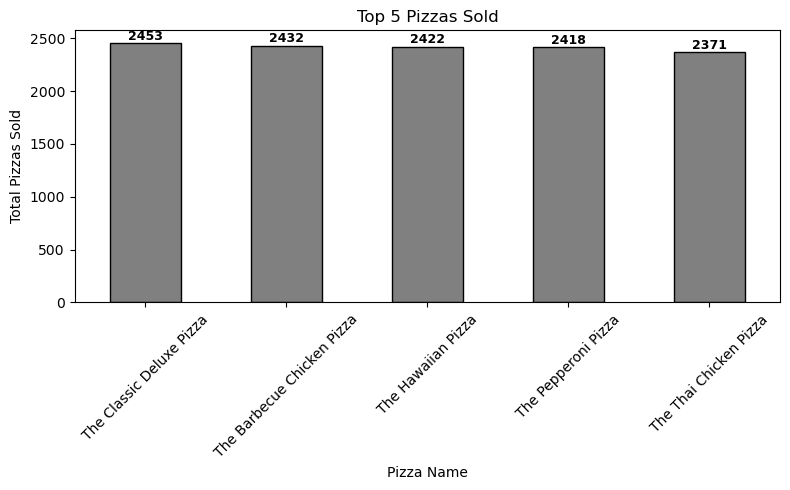

In [61]:
pizzas_by_name = df.groupby("pizza_name")["quantity"].sum()

top5 = pizzas_by_name.sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 5))
ax = top5.plot(kind="bar", color="grey", edgecolor="black")
plt.title("Top 5 Pizzas Sold")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(top5):
    plt.text(i, val + 2, str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

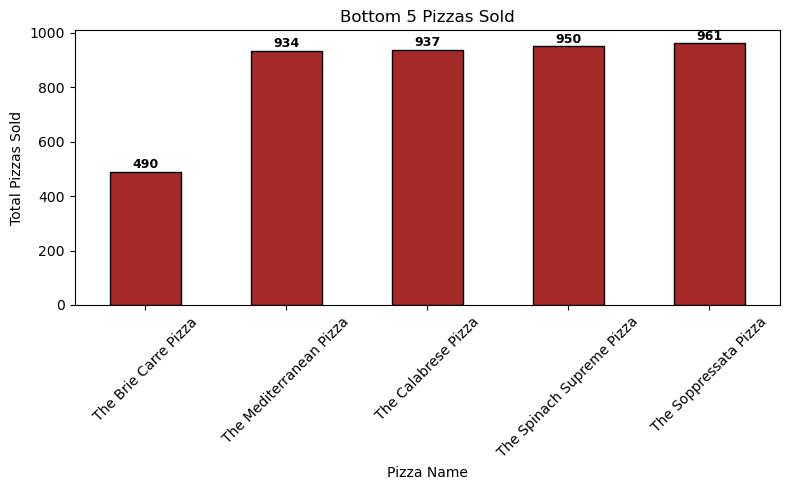

In [62]:
bottom5 = pizzas_by_name.sort_values(ascending=True).head(5)

plt.figure(figsize=(8, 5))
ax = bottom5.plot(kind="bar", color="brown", edgecolor="black")
plt.title("Bottom 5 Pizzas Sold")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(bottom5):
    plt.text(i, val + 2, str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

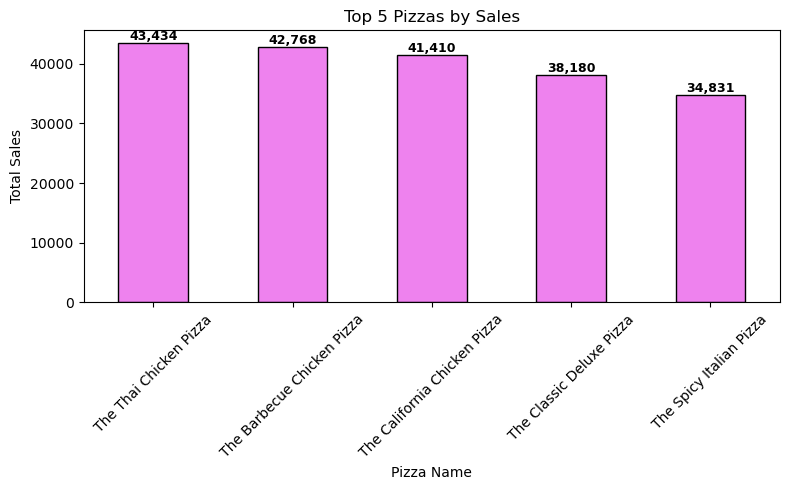

In [66]:
sales_by_name = df.groupby("pizza_name")["total_price"].sum()
top5_sales = sales_by_name.sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 5))
ax = top5_sales.plot(kind="bar", color="violet", edgecolor="black")
plt.title("Top 5 Pizzas by Sales")
plt.xlabel("Pizza Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

for i, val in enumerate(top5_sales):
    plt.text(i, val + 10, f"{val:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

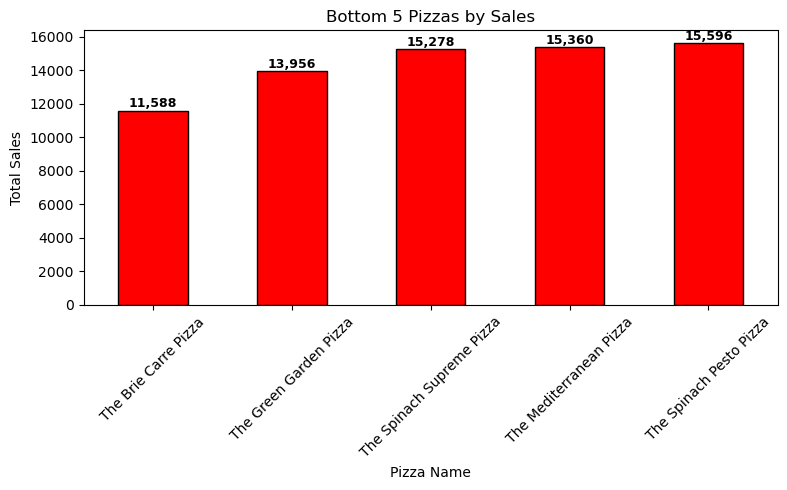

In [65]:
bottom5_sales = sales_by_name.sort_values(ascending=True).head(5)

plt.figure(figsize=(8, 5))
ax = bottom5_sales.plot(kind="bar", color="red", edgecolor="black")
plt.title("Bottom 5 Pizzas by Sales")
plt.xlabel("Pizza Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

for i, val in enumerate(bottom5_sales):
    plt.text(i, val + 10, f"{val:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()